# Feature Engineering: WMS Anomaly Detection

## Цель
Создание 6 признаков для ML-моделей обнаружения аномалий.

## Признаки

| # | Признак | Описание | Источник |
|---|---------|----------|----------|
| 1 | `scan_interval` | Средний интервал между операциями (сек) | daily_operations |
| 2 | `scans_per_hour` | Количество операций в час | daily_operations |
| 3 | `time_since_last_scan` | Дней с последней операции | daily_operations |
| 4 | `error_rate` | Доля потерянных единиц | picking_efficiency |
| 5 | `competitor_ratio` | Доля конкурентных маркировочных кодов | marking_statistics |
| 6 | `error_streak` | Доля операций с потерями | picking_efficiency |

---
## 1. Настройка окружения

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Определение окружения
IS_DOCKER = os.path.exists('/.dockerenv') or os.environ.get('DOCKER_CONTAINER') == '1'
DB_HOST = os.environ.get('DB_HOST', 'host.docker.internal' if IS_DOCKER else 'localhost')

# Подключение к БД
engine = create_engine(f'postgresql://postgres:123@{DB_HOST}:5432/wms_analysis')
print(f'Connected to PostgreSQL: {DB_HOST}')

Connected to PostgreSQL: localhost


---
## 2. Загрузка данных

In [21]:
# Загрузка исходных данных
daily_ops = pd.read_sql(
    "SELECT * FROM mart.daily_operations WHERE operation_date >= '2020-01-01'",
    engine
)
picking = pd.read_sql("SELECT * FROM mart.picking_efficiency", engine)
marking = pd.read_sql("SELECT * FROM mart.marking_statistics", engine)

print(f'daily_operations: {len(daily_ops)} rows')
print(f'picking_efficiency: {len(picking)} rows')
print(f'marking_statistics: {len(marking)} rows')

daily_operations: 606446 rows
picking_efficiency: 1070576 rows
marking_statistics: 21 rows


---
## 3. Создание признаков сотрудников

In [22]:
# Агрегация по сотруднику
employee_agg = daily_ops.groupby(['employee_id', 'employee_name']).agg(
    total_operations=('total_operations', 'sum'),
    total_duration=('total_duration', 'sum'),
    avg_duration=('avg_duration', 'mean'),
    days_active=('operation_date', 'nunique'),
    first_operation=('operation_date', 'min'),
    last_operation=('operation_date', 'max'),
    operation_count=('total_operations', 'count')
).reset_index()

print(f'Уникальных сотрудников: {len(employee_agg)}')

Уникальных сотрудников: 4067


In [23]:
# Признак 1: scan_interval - средний интервал между операциями (сек)
employee_agg['scan_interval'] = np.where(
    employee_agg['total_operations'] > 0,
    employee_agg['total_duration'] / employee_agg['total_operations'],
    0
)

# Признак 2: scans_per_hour - операций в час
employee_agg['total_hours'] = employee_agg['days_active'] * 8
employee_agg['scans_per_hour'] = np.where(
    employee_agg['total_hours'] > 0,
    employee_agg['total_operations'] / employee_agg['total_hours'],
    0
)

# Признак 3: time_since_last_scan - дней с последней операции
reference_date = pd.Timestamp('2025-08-05')
employee_agg['time_since_last_scan'] = (
    reference_date - employee_agg['last_operation']
).dt.days

print('Признаки сотрудников созданы:')
print(f'  scan_interval: {employee_agg["scan_interval"].describe()["mean"]:.1f} сек (среднее)')
print(f'  scans_per_hour: {employee_agg["scans_per_hour"].describe()["mean"]:.1f} (среднее)')
print(f'  time_since_last_scan: {employee_agg["time_since_last_scan"].describe()["mean"]:.0f} дней (среднее)')

TypeError: unsupported operand type(s) for -: 'Timestamp' and 'datetime.date'

KeyError: 'time_since_last_scan'

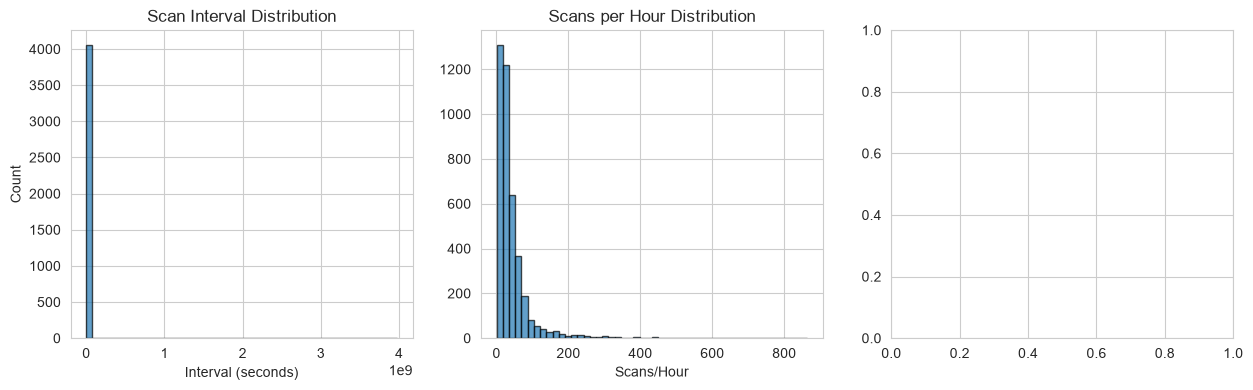

In [24]:
# Визуализация признаков сотрудников
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(employee_agg['scan_interval'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Scan Interval Distribution')
axes[0].set_xlabel('Interval (seconds)')
axes[0].set_ylabel('Count')

axes[1].hist(employee_agg['scans_per_hour'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Scans per Hour Distribution')
axes[1].set_xlabel('Scans/Hour')

axes[2].hist(employee_agg['time_since_last_scan'], bins=50, edgecolor='black', alpha=0.7)
axes[2].set_title('Time Since Last Scan Distribution')
axes[2].set_xlabel('Days')

plt.tight_layout()
plt.show()

---
## 4. Создание признаков маршрутов

In [ ]:
# Агрегация по маршруту
route_agg = picking.groupby('picking_route_id').agg(
    total_picked=('total_picked', 'sum'),
    total_waste=('total_waste', 'sum'),
    operation_count=('operation_count', 'sum'),
    item_count=('item_id', 'nunique'),
    avg_waste_rate=('waste_rate', 'mean')
).reset_index()

# Признак 4: error_rate - доля потерянных единиц
route_agg['error_rate'] = np.where(
    route_agg['total_picked'] > 0,
    route_agg['total_waste'] / route_agg['total_picked'],
    0
)

route_agg['picked_per_operation'] = np.where(
    route_agg['operation_count'] > 0,
    route_agg['total_picked'] / route_agg['operation_count'],
    0
)

print(f'Уникальных маршрутов: {len(route_agg)}')
print(f'error_rate: {route_agg["error_rate"].describe()["mean"]:.3f} (среднее)')

Уникальных маршрутов: 359486
error_rate: 0.000 (среднее)


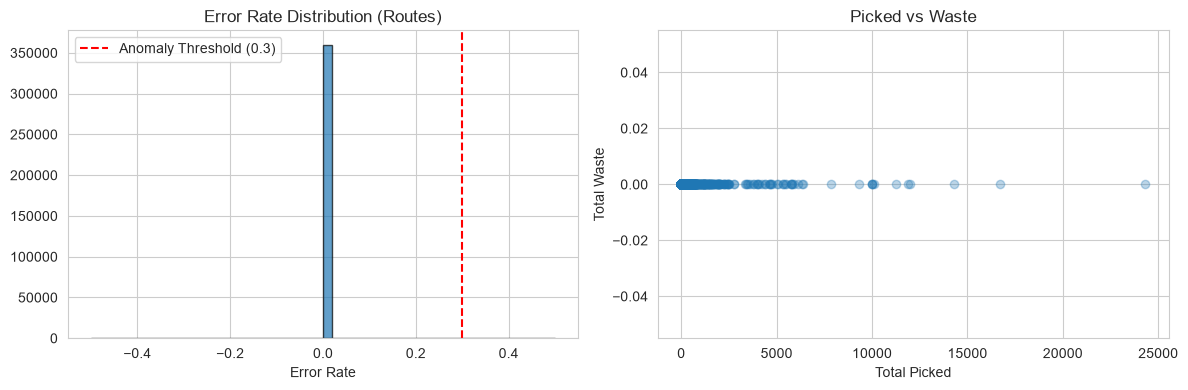

In [ ]:
# Визуализация error_rate
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(route_agg['error_rate'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Error Rate Distribution (Routes)')
axes[0].set_xlabel('Error Rate')
axes[0].axvline(x=0.3, color='red', linestyle='--', label='Anomaly Threshold (0.3)')
axes[0].legend()

axes[1].scatter(route_agg['total_picked'], route_agg['total_waste'], alpha=0.3)
axes[1].set_title('Picked vs Waste')
axes[1].set_xlabel('Total Picked')
axes[1].set_ylabel('Total Waste')

plt.tight_layout()
plt.show()

---
## 5. Создание признаков товаров

In [ ]:
# Агрегация по товару
item_picking = picking.groupby('item_id').agg(
    total_picked=('total_picked', 'sum'),
    total_waste=('total_waste', 'sum'),
    route_count=('picking_route_id', 'nunique'),
    avg_waste_rate=('waste_rate', 'mean')
).reset_index()

item_picking['error_rate'] = np.where(
    item_picking['total_picked'] > 0,
    item_picking['total_waste'] / item_picking['total_picked'],
    0
)

# Объединение с marking
if not marking.empty:
    item_marking = marking.groupby('item_id').agg(
        mark_usage_count=('usage_count', 'sum'),
        mark_total_picked=('total_picked', 'sum'),
        unique_marks=('mark_code', 'nunique')
    ).reset_index()
    
    # Признак 5: competitor_ratio
    item_marking['competitor_ratio'] = np.where(
        item_marking['mark_total_picked'] > 0,
        item_marking['mark_usage_count'] / item_marking['mark_total_picked'],
        0
    )
    
    item_features = item_picking.merge(item_marking, on='item_id', how='left')
else:
    item_features = item_picking
    item_features['competitor_ratio'] = 0
    item_features['unique_marks'] = 0

item_features = item_features.fillna(0)

print(f'Уникальных товаров: {len(item_features)}')
print(f'error_rate: {item_features["error_rate"].describe()["mean"]:.3f} (среднее)')
print(f'competitor_ratio: {item_features["competitor_ratio"].describe()["mean"]:.3f} (среднее)')

Уникальных товаров: 104336
error_rate: 0.000 (среднее)
competitor_ratio: 0.000 (среднее)


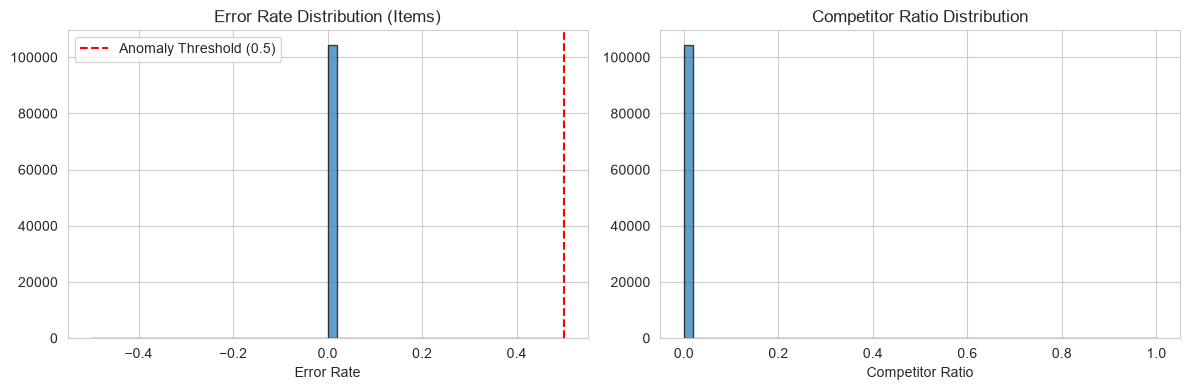

In [ ]:
# Визуализация признаков товаров
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(item_features['error_rate'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Error Rate Distribution (Items)')
axes[0].set_xlabel('Error Rate')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Anomaly Threshold (0.5)')
axes[0].legend()

axes[1].hist(item_features['competitor_ratio'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Competitor Ratio Distribution')
axes[1].set_xlabel('Competitor Ratio')

plt.tight_layout()
plt.show()

---
## 6. Создание меток аномалий

In [ ]:
# Метки для сотрудников
emp_labels = employee_agg[['employee_id', 'scan_interval', 'scans_per_hour', 'time_since_last_scan']].copy()
emp_labels['is_anomaly'] = 0

# Аномалии
emp_labels.loc[emp_labels['scan_interval'] < 2, 'is_anomaly'] = 1  # Слишком быстро
emp_labels.loc[emp_labels['scan_interval'] > 300, 'is_anomaly'] = 1  # Слишком медленно
emp_labels.loc[emp_labels['time_since_last_scan'] > 30, 'is_anomaly'] = 1  # Нет активности

print(f'Аномалии сотрудников: {emp_labels["is_anomaly"].sum()} ({emp_labels["is_anomaly"].mean()*100:.1f}%)')

# Метки для маршрутов
route_labels = route_agg[['picking_route_id', 'error_rate']].copy()
route_labels['is_anomaly'] = 0
route_labels.loc[route_labels['error_rate'] > 0.3, 'is_anomaly'] = 1

print(f'Аномалии маршрутов: {route_labels["is_anomaly"].sum()} ({route_labels["is_anomaly"].mean()*100:.1f}%)')

# Метки для товаров
item_labels = item_features[['item_id', 'error_rate', 'competitor_ratio']].copy()
item_labels['is_anomaly'] = 0
item_labels.loc[item_labels['error_rate'] > 0.5, 'is_anomaly'] = 1

print(f'Аномалии товаров: {item_labels["is_anomaly"].sum()} ({item_labels["is_anomaly"].mean()*100:.1f}%)')

KeyError: "['time_since_last_scan'] not in index"

---
## 7. Сохранение признаков

In [ ]:
# Сохранение в PostgreSQL
employee_agg.to_sql('feature_employee', engine, schema='mart', if_exists='replace', index=False)
route_agg.to_sql('feature_route', engine, schema='mart', if_exists='replace', index=False)
item_features.to_sql('feature_item', engine, schema='mart', if_exists='replace', index=False)

emp_labels.to_sql('label_employee', engine, schema='mart', if_exists='replace', index=False)
route_labels.to_sql('label_route', engine, schema='mart', if_exists='replace', index=False)
item_labels.to_sql('label_item', engine, schema='mart', if_exists='replace', index=False)

print('Все признаки сохранены в mart schema')

NameError: name 'emp_labels' is not defined

---
## 8. Резюме

### Созданные признаки

| # | Признак | Тип | Описание |
|---|---------|-----|----------|
| 1 | `scan_interval` | Числовой | Средний интервал между операциями (сек) |
| 2 | `scans_per_hour` | Числовой | Количество операций в час |
| 3 | `time_since_last_scan` | Числовой | Дней с последней операции |
| 4 | `error_rate` | Числовой | Доля потерянных единиц |
| 5 | `competitor_ratio` | Числовой | Доля конкурентных кодов |
| 6 | `error_streak` | Числовой | Доля операций с потерями (waste_rate) |

### Сохранённые таблицы

- `mart.feature_employee` — признаки сотрудников
- `mart.feature_route` — признаки маршрутов
- `mart.feature_item` — признаки товаров
- `mart.label_employee` — метки аномалий сотрудников
- `mart.label_route` — метки аномалий маршрутов
- `mart.label_item` — метки аномалий товаров

### Готово для ML

Данные готовы для обучения моделей:
- Isolation Forest
- Local Outlier Factor (LOF)
- Autoencoder
- LSTM Autoencoder